# <center> Diviser pour régner <br/> </center>
### <center> <i> Rotation d'une image carrée d'un quart de tour </i> </center> 

#### Objectif :  
Appliquer la méthode « *Diviser pour régner* » afin d'effectuer, sur une image carrée, une rotation d’un quart de tour.

**Méthode valable sur les images carrées dont le côté est une puissance de 2.**

**Introduction en vidéo :** cliquer [ici](https://www.youtube.com/watch?v=OXo-uzzD4Js)

Dans ce problème, on considère une image au format « bitmap » implémentée par un tableau de tableaux, les éléments du tableau étant des triplets d'entiers indiquant le code RVB de l'élément.   

Chaque élément est appelé pixel (Pixel veut dire **pict**ure **el**ement soit image élémentaire (d’une seule couleur) et on peut donc considérer l’image comme une matrice de pixels.  

Pour éviter les complications inutiles, on considère que l’image a autant de pixels en largeur qu’en hauteur (on dit que la matrice est **carrée**) et de plus, on considère que cette dimension commune est une puissance de 2.    

Par exemple, voici une image 512×512 :

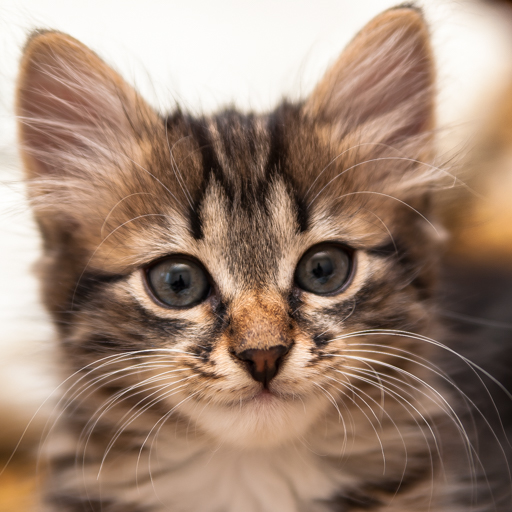


On aimerait faire tourner cette image d’un quart de tour dans le sens des aiguilles d’une montre.   

**Question 1:**   
Combien de pixels en tout, l’image comporte-t-elle ?  ....................... 


**L’algorithme proposé fonctionne ainsi :**

On commence par découper l’image 512 × 512 pixels en 4 images de 256 × 256 pixels, ainsi :

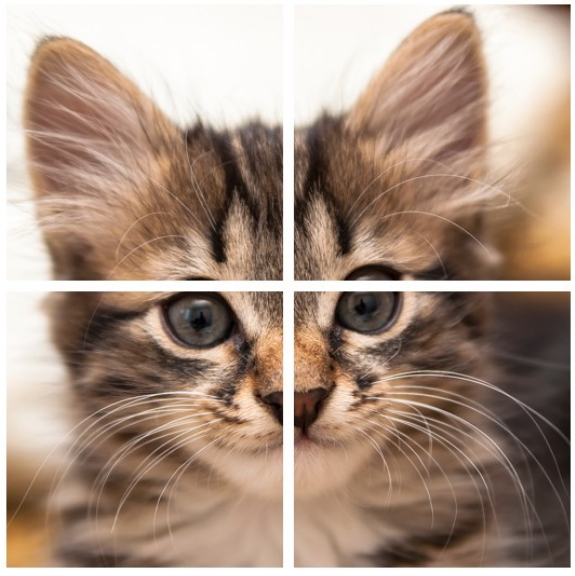


**Question 2 :**  
Combien de pixels chaque image 256 × 256 pixels comporte-t-elle ? ........................

**Etape suivante :**    
L’étape suivante consiste à décaler les 4 images 256 × 256, chacune venant prendre la place de celle qui la suit dans le sens des aiguilles d’une montre :

- Le sud-ouest (l’œil gauche du chat) va au nord-ouest ; 
- le nord-ouest (l’oreille gauche) va au nord-est ;  
- le nord-est (l’oreille droite) va au sud-est ; 
- le sud-est (l’œil droit) va au sud-ouest.  


On obtient alors l’image suivante :  

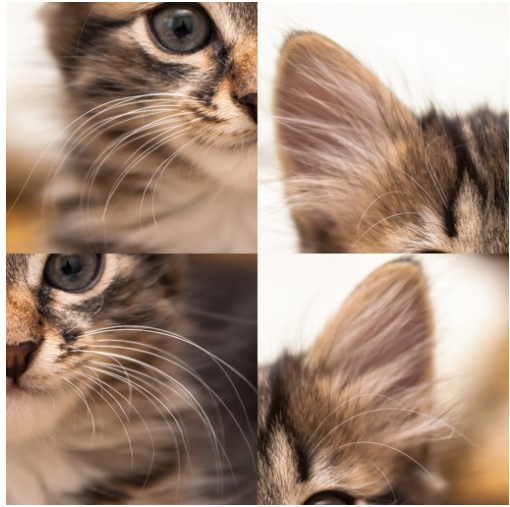

Ensuite, on **fait faire un quart de tour à chacune** des 4 images 256 × 256 :  

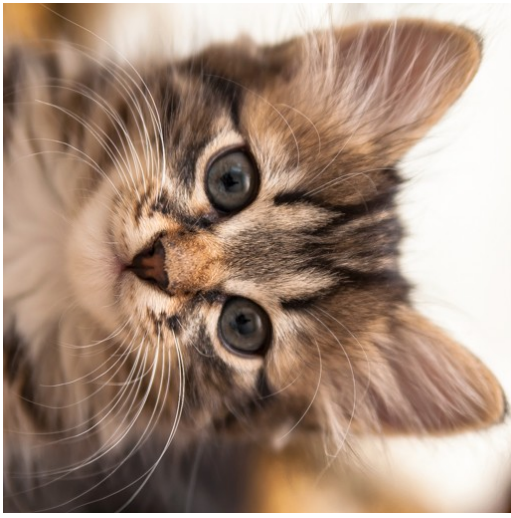

Comme pour faire tourner l’image 512 × 512 pixels, on effectue aussi 4 rotations des images 256 × 256 pixels, l’algorithme proposé est récursif.   

Comme, de plus, les images 256 × 256 sont extraites de l’image 512 × 512, la méthode est diviser pour régner. 


L’algorithme étant récursif, il faut déterminer le cas de base.   
Pour cela, on regarde un détail (au-dessus de l’œil gauche du chat) agrandi :  

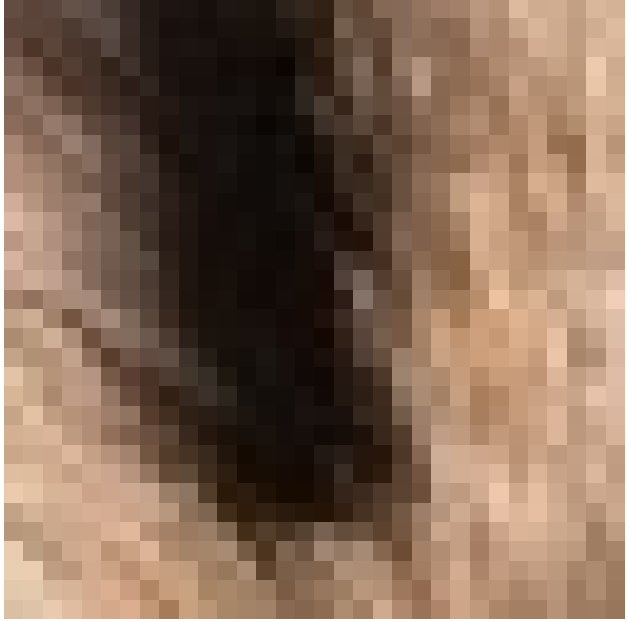


(l’image ci-dessus est de taille 32×32 pixels)  
On voit que chaque pixel est uniformément colorié, par exemple le pixel en haut à gauche du détail ci-dessus ressemble à ceci :  

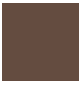

On en déduit le cas de base : **Tourner une image de 1×1 pixel, c’est ne rien faire du tout**.  

**Question 3 :**    
Pour évaluer la complexité de cet algorithme, on ne compte que les décalages.  

* Lors du premier appel récursif, on a décalé 4 images 256 × 256, ce qui représente 4 décalages.   

* Ensuite, 
- On effectue en tout 16 décalages d’images 128 × 128.
- On effectue en tout 64 décalages d’images 64×64.  
- On effectue en tout 256 décalages d’images 32×32.  
- On effectue en tout 1 024 décalages d’images 16×16.  
- On effectue en tout 4 096 décalages d’images 8×8.  
- On effectue en tout 16 384 décalages d’images 4×4.  
- On effectue en tout 65 536 décalages d’images 2×2.  
- On effectue en tout 262 144 décalages d’images 1×1. 

Le nombre total de décalages est alors : $4+16+64+256+1024+...+262 144 = 4 \times (1+4+4^2+4^3+...+4^8) = 4 \times \frac{1-4^9}{1-4} = \frac{4}{3} \times (4^9-1) = \frac{4}{3} \times (512^2-1) = 349524$ 


On voudrait maintenant automatiser le décompte des déplacements (de pixels ou de blocs de pixels) nécessaires
pour faire tourner d’un quart de tour, une image de dimensions $2^e \times 2^e$ où $e$ est l’exposant. Pour cela,
on définit une fonction `ndep` (nombre de déplacements) dépendant de l’exposant `e`.

Compléter le code de cette fonction Python donnée ci-dessous pour qu’elle renvoie le nombre de décalages nécessaires pour faire tourner une image de $2^e$ pixels en largeur et en hauteur.


In [ ]:
def ndep(e) :
    if e==0 :
        return 0
    else :
        return 4*ndep(e-1) + 4

assert ndep(9) == 349524
    

Pour faire tourner non récursivement une image de $2^e \times  2^e$ pixels, on a besoin d’effectuer $2^e \times  2^e$ déplacements (d’un pixel chacun).   
On rappelle que $2^e \times  2^e= 4^e $. 

Voici la représentation graphique de `ndep(e) / 4**e ` :

In [ ]:
import matplotlib.pyplot as plt

x = [e for e in range(20)]                # Liste des abscisses
y = [ndep(e) / 4**e for e in range(20)]   # Liste des ordonnées

plt.plot(x,y,'ro') # r pour red, o pour un cercle.
plt.show()

Peut-on considérer l’algorithme récursif comme efficace, par rapport à l’algorithme consistant à déplacer chaque pixel après avoir calculé ses nouvelles coordonnées ?

**Votre réponse :**

## Implémentation en Python
Le code suivant applique ce procédé

**Etape 1 :**     
On commence par charger l'image en mémoire.


In [ ]:
from PIL import Image

image = Image.open("images/cat.png")
display(image)
largeur, hauteur = image.size
px = image.load()


* La variable `px` est la matrice de pixels constituant l'image.  


* On peut par exemple récupérer la valeur des composantes (Rouge, Vert, Bleu) d'un pixel par l'instruction :

In [ ]:
print(px[511,511])

**Etape 2 :**    
Il est nécessaire d'écrire une fonction `permutation_circulaire` qui réalise la permutation des pixels entre les 4 sous-images selon le principe illustré par le schéma suivant : 

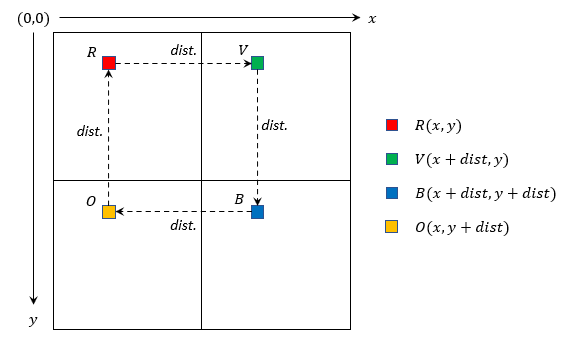

In [ ]:
def permutation_circulaire(px, x, y, dist):
    if dist < 1:
        return None
    tmp = px[x, y]
    px[x, y] = px[x, y + dist]
    px[x, y + dist] = px[x + dist, y + dist]
    px[x + dist, y + dist] = px[x + dist, y]
    px[x + dist, y] = tmp
    

**Question :**  
A quoi sert la variable `tmp` ?   

La variable `tmp` est une variable temporaire qui sert à stocker les informations du pixel de coordonnées (x ; y) afin de ne pas perdre ces informations.

**Etape 3 :**   
L’algorithme a été programmé ci-dessous en Python, sous la forme de la fonction `rotation`.  
Elle utilise le fait que l’import d’une image par la fonction `load` de PIL donne un tableau à deux dimensions.

In [ ]:
def rotation_aux(px, x, y, taille):
    if taille == 1:
        return
    
    t = taille // 2             
    for i in range(x,x + t):
        for j in range(y, y + t):
            permutation_circulaire(px, i, j, t)
            
    rotation_aux(px, x, y, t)
    rotation_aux(px, x + t, y, t)
    rotation_aux(px, x, y + t , t)
    rotation_aux(px, x + t, y + t, t)
            
def rotation(px, taille):
    rotation_aux(px,0,0,taille)

**Etape 4 :**  
Pour appliquer et visualiser le résultat de l'algorithme, on exécute :  

In [ ]:
rotation(px, largeur)
display(image)

**Exercice :**

Modifier la fonction `permutation` afin que la rotation de l'image se fasse à présent dans le sens anti-horaire. 

**Sources :**
* [monlyceenumerique.fr](http://www.monlyceenumerique.fr/nsi_terminale/a/a3_div_regner.php)